# QSOLVE Agriculture Track 1
## Mentor Scaling Experiment — QAOA from 2 to 7 Factories

This notebook follows the mentor feedback exactly: **start with 2 factories, inspect the result, then scale to 3, 4, 5, 6, and 7 factories**.

For every instance we record the number of possible routes, qubits, exact best route, QAOA route, transport cost, approximation ratio, probability of the exact optimum, feasible-state probability, runtime, distance, and travel time.

### Quantum encoding
We use **QAOA with compact permutation-index encoding**. Each possible factory ordering is assigned an integer basis state. For `n` factories there are `n!` possible routes, so the number of qubits is

\[
q=\lceil\log_2(n!)\rceil.
\]

This uses **1, 3, 5, 7, 10, 13 qubits** for 2–7 factories, instead of **4, 9, 16, 25, 36, 49 qubits** for the earlier `n²` position-CUBO encoding.

> This is a controlled quantum **route-ordering benchmark**. Each instance uses the real OSM roads and real demand proportions, but the included demands are normalized to a single 10-tonne truck so all selected factories belong to one multi-factory route. The full 233.7-tonne distribution problem remains hybrid.

In [1]:
# qBraid Lab setup — run once, then restart the kernel if requested.
%pip install -q "qiskit>=2.3,<3" "qbraid>=0.12" numpy pandas scipy matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, math, time
from itertools import permutations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit import QuantumCircuit
from qiskit.circuit.library import DiagonalGate

MASTER_SEED = 42
QAOA_P = 1
MAXITER = 120
QAOA_RESTARTS = 3
SHOTS = 4096
INVALID_ENERGY = 2.0
SCALING_SIZES = [2, 3, 4, 5, 6, 7]

np.random.seed(MASTER_SEED)

print('QAOA p:', QAOA_P)
print('Restarts:', QAOA_RESTARTS)
print('Shots:', SHOTS)
print('Scaling sizes:', SCALING_SIZES)

QAOA p: 1
Restarts: 3
Shots: 4096
Scaling sizes: [2, 3, 4, 5, 6, 7]


## 1. Load the same frozen QSOLVE dataset

In [3]:
DATA_FILE = 'QSOLVE_Quantum_Ready_Dataset_frozen.xlsx'
DEPOT = 'Karatina'
FACTORIES = ['Ragati','Nguguini','Kiangai','Thunguri','Kianjega','Chema','Mukangu']
DEMAND_FALLBACK = {
    'Ragati': 28.380, 'Nguguini': 73.092, 'Kiangai': 36.489,
    'Thunguri': 37.170, 'Kianjega': 24.522, 'Chema': 10.848,
    'Mukangu': 23.199,
}
LABELS = [DEPOT] + FACTORIES

D_FALLBACK = np.array([
    [0,11.82,18.92,20.02,23.13,13.11,11.95,10.08],
    [11.82,0,15.86,29.64,34.81,25.51,11.53,21.86],
    [18.92,15.86,0,19.08,40.65,20.23,9.84,24.95],
    [20.02,29.64,19.08,0,38.90,7.71,21.17,21.38],
    [23.13,34.81,40.65,38.90,0,32.26,33.69,24.62],
    [13.11,25.51,20.23,7.71,32.26,0,19.38,14.75],
    [11.95,11.53,9.84,21.17,33.69,19.38,0,18.26],
    [10.08,21.86,24.95,21.38,24.62,14.75,18.26,0],
], float)
T_FALLBACK = np.array([
    [0,0.27,0.44,0.29,0.52,0.14,0.28,0.22],
    [0.27,0,0.38,0.55,0.79,0.42,0.28,0.47],
    [0.44,0.38,0,0.44,0.92,0.43,0.23,0.57],
    [0.29,0.55,0.44,0,0.79,0.15,0.51,0.43],
    [0.52,0.79,0.92,0.79,0,0.63,0.75,0.56],
    [0.14,0.42,0.43,0.15,0.63,0,0.35,0.28],
    [0.28,0.28,0.23,0.51,0.75,0.35,0,0.41],
    [0.22,0.47,0.57,0.43,0.56,0.28,0.41,0],
], float)

if os.path.exists(DATA_FILE):
    nodes_df = pd.read_excel(DATA_FILE, sheet_name='Nodes_Demand')
    DIST = pd.read_excel(DATA_FILE, sheet_name='Distance_Matrix', index_col=0).astype(float)
    TIME = pd.read_excel(DATA_FILE, sheet_name='Travel_Time_Matrix', index_col=0).astype(float)
    ROUTE_ALLOWED = pd.read_excel(DATA_FILE, sheet_name='Route_Allowed', index_col=0).astype(int)
    params_df = pd.read_excel(DATA_FILE, sheet_name='Parameters')
    params = dict(zip(params_df['Parameter'], params_df['Value']))
    frows = nodes_df[nodes_df['Type'].str.lower() == 'factory']
    DEMAND = dict(zip(frows['Location'], frows['Demand_tonnes'].astype(float)))
    DEPOT_STOCK = float(params['Depot stock'])
    TRUCK_CAPACITY = float(params['Truck capacity'])
    TRANSPORT_RATE = float(params['Transport rate'])
    MAX_ROUTE_TIME = float(params['Maximum route duration'])
    print('Loaded:', DATA_FILE)
else:
    DEMAND = DEMAND_FALLBACK.copy()
    DIST = pd.DataFrame(D_FALLBACK, index=LABELS, columns=LABELS)
    TIME = pd.DataFrame(T_FALLBACK, index=LABELS, columns=LABELS)
    A = np.ones((8,8), int); np.fill_diagonal(A, 0)
    ROUTE_ALLOWED = pd.DataFrame(A, index=LABELS, columns=LABELS)
    DEPOT_STOCK, TRUCK_CAPACITY, TRANSPORT_RATE, MAX_ROUTE_TIME = 410.0, 10.0, 16.0, 8.0
    print('Using embedded frozen dataset.')

TOTAL_DEMAND = sum(DEMAND.values())
assert abs(TOTAL_DEMAND - 233.700) < 1e-6
assert abs(TRUCK_CAPACITY - 10.0) < 1e-9

print('Original total demand:', TOTAL_DEMAND, 't')
print('Truck capacity:', TRUCK_CAPACITY, 't')
print('Transport rate:', TRANSPORT_RATE, 'KSh/t-km')

Loaded: QSOLVE_Quantum_Ready_Dataset_frozen.xlsx
Original total demand: 233.7 t
Truck capacity: 10.0 t
Transport rate: 16.0 KSh/t-km


## 2. Create nested 2→7 factory instances

In [4]:
# Add factories nearest to Karatina first so every larger instance contains the previous one.
SCALE_ORDER = sorted(FACTORIES, key=lambda f: float(DIST.loc[DEPOT, f]))

scaling_order_df = pd.DataFrame({
    'Addition_Order': range(1, 8),
    'Factory': SCALE_ORDER,
    'Distance_From_Karatina_km': [float(DIST.loc[DEPOT,f]) for f in SCALE_ORDER],
    'Original_Demand_t': [DEMAND[f] for f in SCALE_ORDER],
})

display(scaling_order_df)
print('Nested order:', ' -> '.join(SCALE_ORDER))

,Addition_Order,Factory,Distance_From_Karatina_km,Original_Demand_t
0,1,Mukangu,10.08,23.199
1,2,Ragati,11.82,28.380
2,3,Chema,11.95,10.848
3,4,Kianjega,13.11,24.522
4,5,Nguguini,18.92,73.092
5,6,Kiangai,20.02,36.489
6,7,Thunguri,23.13,37.170


Nested order: Mukangu -> Ragati -> Chema -> Kianjega -> Nguguini -> Kiangai -> Thunguri


In [5]:
def make_scaled_deliveries(factories):
    raw = sum(DEMAND[f] for f in factories)
    q = {f: TRUCK_CAPACITY * DEMAND[f] / raw for f in factories}
    q[factories[-1]] += TRUCK_CAPACITY - sum(q.values())
    return q

load_rows = []
for n in SCALING_SIZES:
    fs = SCALE_ORDER[:n]
    q = make_scaled_deliveries(fs)
    for f in fs:
        load_rows.append({
            'Factories_in_Instance': n,
            'Factory': f,
            'Original_Demand_t': DEMAND[f],
            'Scaled_Delivery_t': q[f],
        })
instance_loads_df = pd.DataFrame(load_rows)
display(instance_loads_df)

,Factories_in_Instance,Factory,Original_Demand_t,Scaled_Delivery_t
0,2,Mukangu,23.199,4.497761
1,2,Ragati,28.380,5.502239
2,3,Mukangu,23.199,3.716180
3,3,Ragati,28.380,4.546110
4,3,Chema,10.848,1.737710
5,4,Mukangu,23.199,2.668116
6,4,Ragati,28.380,3.263982
7,4,Chema,10.848,1.247628
8,4,Kianjega,24.522,2.820274
9,5,Mukangu,23.199,1.449566


## 3. Exact route objective and logistics constraints

In [6]:
def evaluate_route(order, deliveries):
    current = DEPOT
    load = float(sum(deliveries.values()))
    distance = time_h = tonne_km = cost = 0.0
    legs = []

    for factory in order:
        if int(ROUTE_ALLOWED.loc[current, factory]) != 1:
            return {'feasible': False, 'reason': 'road restriction'}
        d, t = float(DIST.loc[current,factory]), float(TIME.loc[current,factory])
        tk = load * d
        c = TRANSPORT_RATE * tk
        delivered = float(deliveries[factory])
        legs.append({'From':current,'To':factory,'Load_t':load,'Delivered_t':delivered,
                     'Distance_km':d,'Time_h':t,'Tonne_km':tk,'Cost_KSh':c})
        distance += d; time_h += t; tonne_km += tk; cost += c
        load -= delivered
        current = factory

    d, t = float(DIST.loc[current,DEPOT]), float(TIME.loc[current,DEPOT])
    legs.append({'From':current,'To':DEPOT,'Load_t':load,'Delivered_t':0.0,
                 'Distance_km':d,'Time_h':t,'Tonne_km':load*d,
                 'Cost_KSh':TRANSPORT_RATE*load*d})
    distance += d; time_h += t; tonne_km += load*d; cost += TRANSPORT_RATE*load*d

    feasible = (time_h <= MAX_ROUTE_TIME + 1e-9 and abs(load) <= 1e-8 and
                sum(deliveries.values()) <= TRUCK_CAPACITY + 1e-9)
    return {'feasible':feasible,'order':tuple(order),'distance_km':distance,'time_h':time_h,
            'tonne_km':tonne_km,'cost_ksh':cost,'remaining_load_t':load,'legs':legs}

## 4. Build the compact quantum route-index instance

In [7]:
def build_quantum_instance(n):
    factories = SCALE_ORDER[:n]
    deliveries = make_scaled_deliveries(factories)
    routes = list(permutations(factories))
    rows = []
    for rank, route in enumerate(routes):
        m = evaluate_route(route, deliveries)
        rows.append({
            'Route_Rank': rank,
            'Route': route,
            'Route_String': DEPOT+' -> '+' -> '.join(route)+' -> '+DEPOT,
            'Feasible': bool(m['feasible']),
            'Cost_KSh': m.get('cost_ksh', np.nan),
            'Distance_km': m.get('distance_km', np.nan),
            'Time_h': m.get('time_h', np.nan),
        })
    route_df = pd.DataFrame(rows)
    feasible = route_df[route_df['Feasible']].copy()
    if feasible.empty: raise RuntimeError('No feasible route.')
    exact_row = route_df.loc[feasible['Cost_KSh'].idxmin()]

    n_routes = math.factorial(n)
    n_qubits = math.ceil(math.log2(n_routes))
    dimension = 2**n_qubits
    scale = float(feasible['Cost_KSh'].max())
    energies = np.full(dimension, INVALID_ENERGY, float)
    feasible_ranks = []
    for _, row in route_df.iterrows():
        r = int(row['Route_Rank'])
        if row['Feasible']:
            energies[r] = float(row['Cost_KSh']) / scale
            feasible_ranks.append(r)
    return {
        'n':n,'factories':factories,'deliveries':deliveries,'routes':routes,
        'route_df':route_df,'exact_row':exact_row,'n_routes':n_routes,
        'n_qubits':n_qubits,'dimension':dimension,'energies':energies,
        'feasible_ranks':np.asarray(feasible_ranks,int),'cost_scale':scale,
    }

resource_df = pd.DataFrame([
    {'Factories':n,'Possible_Routes':math.factorial(n),'Position_CUBO_Qubits':n*n,
     'Compact_QAOA_Qubits':math.ceil(math.log2(math.factorial(n))),
     'Compact_State_Space':2**math.ceil(math.log2(math.factorial(n)))}
    for n in SCALING_SIZES
])
display(resource_df)

,Factories,Possible_Routes,Position_CUBO_Qubits,Compact_QAOA_Qubits,Compact_State_Space
0,2,2,4,1,2
1,3,6,9,3,8
2,4,24,16,5,32
3,5,120,25,7,128
4,6,720,36,10,1024
5,7,5040,49,13,8192


## 5. QAOA state-vector simulator

In [8]:
def apply_x_mixer(state, beta, n_qubits):
    out = state.copy()
    c, s = np.cos(beta), -1j*np.sin(beta)
    for q in range(n_qubits):
        stride = 1 << q
        view = out.reshape(-1, 2, stride)
        a, b = view[:,0,:].copy(), view[:,1,:].copy()
        view[:,0,:] = c*a + s*b
        view[:,1,:] = s*a + c*b
        out = view.reshape(-1)
    return out

def qaoa_state(energies, n_qubits, params, p=1):
    state = np.ones(len(energies), complex) / np.sqrt(len(energies))
    gammas = np.asarray(params[:p], float)
    betas = np.asarray(params[p:2*p], float)
    for layer in range(p):
        state *= np.exp(-1j * gammas[layer] * energies)
        state = apply_x_mixer(state, betas[layer], n_qubits)
    return state

def qaoa_expectation(params, energies, n_qubits, p=1):
    state = qaoa_state(energies, n_qubits, params, p)
    probs = np.abs(state)**2
    return float(np.dot(probs, energies))

In [9]:
def solve_qaoa_instance(instance, p=QAOA_P, maxiter=MAXITER,
                        restarts=QAOA_RESTARTS, shots=SHOTS, seed=MASTER_SEED):
    energies, nq = instance['energies'], instance['n_qubits']
    rdf, feasible_ranks = instance['route_df'], instance['feasible_ranks']
    t0 = time.perf_counter(); best = None

    for restart in range(restarts):
        rng = np.random.default_rng(seed + 1000*instance['n'] + restart)
        initial = np.r_[rng.uniform(0,2*np.pi,p), rng.uniform(0,np.pi,p)]
        res = minimize(qaoa_expectation, initial, args=(energies,nq,p), method='COBYLA',
                       options={'maxiter':maxiter,'rhobeg':0.5,'catol':1e-6})
        if best is None or res.fun < best.fun: best = res

    runtime = time.perf_counter() - t0
    probs = np.abs(qaoa_state(energies,nq,best.x,p))**2
    probs /= probs.sum()

    exact_cost = float(instance['exact_row']['Cost_KSh'])
    optimal_ranks = rdf.loc[rdf['Feasible'] & np.isclose(rdf['Cost_KSh'], exact_cost, atol=1e-8),
                            'Route_Rank'].astype(int).to_numpy()
    optimal_probability = float(probs[optimal_ranks].sum())
    feasible_probability = float(probs[feasible_ranks].sum())

    mode_rank = int(feasible_ranks[np.argmax(probs[feasible_ranks])])
    mode_row = rdf.loc[rdf['Route_Rank']==mode_rank].iloc[0]

    rng = np.random.default_rng(seed + 9000 + instance['n'])
    samples = rng.choice(len(probs), size=shots, p=probs)
    counts = np.bincount(samples, minlength=len(probs))
    observed = [int(r) for r in feasible_ranks if counts[int(r)] > 0]
    best_sampled_rank = min(observed, key=lambda r: float(rdf.loc[rdf['Route_Rank']==r,'Cost_KSh'].iloc[0])) if observed else None
    best_sampled_row = rdf.loc[rdf['Route_Rank']==best_sampled_rank].iloc[0] if best_sampled_rank is not None else None

    top = []
    for r in np.argsort(probs)[::-1][:10]:
        r = int(r)
        if r < instance['n_routes']:
            rr = rdf.loc[rdf['Route_Rank']==r].iloc[0]
            route, feas, cost = rr['Route_String'], bool(rr['Feasible']), rr['Cost_KSh']
        else:
            route, feas, cost = 'INVALID STATE', False, np.nan
        top.append({'State_Rank':r,'Bitstring':format(r,f'0{nq}b'),'Probability':probs[r],
                    'Observed_Count':int(counts[r]),'Feasible':feas,'Route':route,'Cost_KSh':cost})

    sampled_cost = float(best_sampled_row['Cost_KSh']) if best_sampled_row is not None else np.nan
    return {
        'n':instance['n'],'factories':instance['factories'],'n_routes':instance['n_routes'],
        'n_qubits':nq,'state_space':instance['dimension'],
        'exact_route':instance['exact_row']['Route_String'],'exact_cost_ksh':exact_cost,
        'exact_distance_km':float(instance['exact_row']['Distance_km']),
        'exact_time_h':float(instance['exact_row']['Time_h']),
        'mode_route':mode_row['Route_String'],'mode_cost_ksh':float(mode_row['Cost_KSh']),
        'mode_ratio':float(mode_row['Cost_KSh'])/exact_cost,
        'best_sampled_route':best_sampled_row['Route_String'] if best_sampled_row is not None else None,
        'best_sampled_cost_ksh':sampled_cost,
        'best_sampled_ratio':sampled_cost/exact_cost if best_sampled_row is not None else np.nan,
        'optimal_probability':optimal_probability,'feasible_probability':feasible_probability,
        'runtime_seconds':runtime,'expected_energy':float(best.fun),
        'optimal_params':np.asarray(best.x,float),'probabilities':probs,'counts':counts,
        'top_probability_df':pd.DataFrame(top),
    }

# 6. Mentor Step 1 — **Run 2 factories only**

In [10]:
instance_2 = build_quantum_instance(2)
print('Factories:', instance_2['factories'])
print('Scaled deliveries:', instance_2['deliveries'])
print('Possible routes:', instance_2['n_routes'])
print('Qubits:', instance_2['n_qubits'])
display(instance_2['route_df'][['Route_Rank','Route_String','Cost_KSh','Distance_km','Time_h']])

Factories: ['Mukangu', 'Ragati']
Scaled deliveries: {'Mukangu': 4.497760716570697, 'Ragati': 5.502239283429303}
Possible routes: 2
Qubits: 1


,Route_Rank,Route_String,Cost_KSh,Distance_km,Time_h
0,0,Karatina -> Mukangu -> Ragati -> Karatina,3537.263212,43.76,0.96
1,1,Karatina -> Ragati -> Mukangu -> Karatina,3464.336788,43.76,0.96


In [11]:
result_2 = solve_qaoa_instance(instance_2)
print('='*90)
print('2-FACTORY QAOA RESULT')
print('='*90)
print('Exact route:', result_2['exact_route'])
print(f"Exact cost: KSh {result_2['exact_cost_ksh']:,.2f}")
print('\nMost-probable feasible QAOA route:', result_2['mode_route'])
print(f"QAOA mode cost: KSh {result_2['mode_cost_ksh']:,.2f}")
print(f"Approximation ratio: {result_2['mode_ratio']:.6f}")
print(f"Probability of exact optimum: {100*result_2['optimal_probability']:.2f}%")
print(f"Feasible-state probability: {100*result_2['feasible_probability']:.2f}%")
print(f"Runtime: {result_2['runtime_seconds']:.4f} s")
display(result_2['top_probability_df'])

2-FACTORY QAOA RESULT
Exact route: Karatina -> Ragati -> Mukangu -> Karatina
Exact cost: KSh 3,464.34

Most-probable feasible QAOA route: Karatina -> Ragati -> Mukangu -> Karatina
QAOA mode cost: KSh 3,464.34
Approximation ratio: 1.000000
Probability of exact optimum: 61.07%
Feasible-state probability: 100.00%
Runtime: 0.5126 s


,State_Rank,Bitstring,Probability,Observed_Count,Feasible,Route,Cost_KSh
0,1,1,0.610655,2460,True,Karatina -> Ragati -> Mukangu -> Karatina,3464.336788
1,0,0,0.389345,1636,True,Karatina -> Mukangu -> Ragati -> Karatina,3537.263212


## 7. After reviewing the 2-factory result, scale to 3, 4, 5, 6, and 7

In [13]:
all_instances = {2: instance_2}
all_results = {2: result_2}

for n in [3,4,5,6,7]:
    print('\n' + '#'*95)
    print(f'SCALING TO {n} FACTORIES')
    print('#'*95)
    instance = build_quantum_instance(n)
    result = solve_qaoa_instance(instance)
    all_instances[n], all_results[n] = instance, result

    print('Factories:', instance['factories'])
    print('Scaled load:', {k: round(v,4) for k,v in instance['deliveries'].items()})
    print(f"Possible routes: {instance['n_routes']:,}")
    print('Compact qubits:', instance['n_qubits'], '| Original n² CUBO qubits:', n*n)
    print('Exact route:', result['exact_route'])
    print(f"Exact cost: KSh {result['exact_cost_ksh']:,.2f}")
    print('QAOA route:', result['mode_route'])
    print(f"QAOA cost: KSh {result['mode_cost_ksh']:,.2f}")
    print(f"Approximation ratio: {result['mode_ratio']:.6f}")
    print(f"Optimal probability: {100*result['optimal_probability']:.2f}%")
    print(f"Runtime: {result['runtime_seconds']:.4f} s")


###############################################################################################
SCALING TO 3 FACTORIES
###############################################################################################
Factories: ['Mukangu', 'Ragati', 'Chema']
Scaled load: {'Mukangu': 3.7162, 'Ragati': 4.5461, 'Chema': 1.7377}
Possible routes: 6
Compact qubits: 3 | Original n² CUBO qubits: 9
Exact route: Karatina -> Ragati -> Chema -> Mukangu -> Karatina
Exact cost: KSh 3,983.05
QAOA route: Karatina -> Mukangu -> Chema -> Ragati -> Karatina
QAOA cost: KSh 4,287.35
Approximation ratio: 1.076397
Optimal probability: 23.00%
Runtime: 0.1883 s

###############################################################################################
SCALING TO 4 FACTORIES
###############################################################################################
Factories: ['Mukangu', 'Ragati', 'Chema', 'Kianjega']
Scaled load: {'Mukangu': 2.6681, 'Ragati': 3.264, 'Chema': 1.2476, 'Kianjega': 2.8203}

## 8. Combined scaling results

In [14]:
rows = []
for n in SCALING_SIZES:
    r = all_results[n]
    rows.append({
        'Factories':n,
        'Factory_Set':' | '.join(r['factories']),
        'Possible_Routes':r['n_routes'],
        'Compact_Qubits':r['n_qubits'],
        'Position_CUBO_Qubits':n*n,
        'State_Space':r['state_space'],
        'Exact_Route':r['exact_route'],
        'Exact_Cost_KSh':r['exact_cost_ksh'],
        'QAOA_Mode_Route':r['mode_route'],
        'QAOA_Mode_Cost_KSh':r['mode_cost_ksh'],
        'Mode_Approximation_Ratio':r['mode_ratio'],
        'Best_Sampled_Route':r['best_sampled_route'],
        'Best_Sampled_Cost_KSh':r['best_sampled_cost_ksh'],
        'Best_Sampled_Approx_Ratio':r['best_sampled_ratio'],
        'Optimal_Probability':r['optimal_probability'],
        'Feasible_Probability':r['feasible_probability'],
        'Exact_Distance_km':r['exact_distance_km'],
        'Exact_Time_h':r['exact_time_h'],
        'Runtime_seconds':r['runtime_seconds'],
        'QAOA_p':QAOA_P,'Shots':SHOTS,'Restarts':QAOA_RESTARTS,
    })
scaling_results_df = pd.DataFrame(rows)
display(scaling_results_df)

,Factories,Factory_Set,Possible_Routes,Compact_Qubits,Position_CUBO_Qubits,State_Space,Exact_Route,Exact_Cost_KSh,QAOA_Mode_Route,QAOA_Mode_Cost_KSh,...,Best_Sampled_Cost_KSh,Best_Sampled_Approx_Ratio,Optimal_Probability,Feasible_Probability,Exact_Distance_km,Exact_Time_h,Runtime_seconds,QAOA_p,Shots,Restarts
0,2,Mukangu | Ragati,2,1,4,2,Karatina -> Ragati -> Mukangu -> Karatina,3464.336788,Karatina -> Ragati -> Mukangu -> Karatina,3464.336788,...,3464.336788,1.0,0.610655,1.000000,43.76,0.96,0.512566,1,4096,3
1,3,Mukangu | Ragati | Chema,6,3,9,8,Karatina -> Ragati -> Chema -> Mukangu -> Kara...,3983.052948,Karatina -> Mukangu -> Chema -> Ragati -> Kara...,4287.347052,...,3983.052948,1.0,0.229962,0.973015,51.69,1.18,0.188282,1,4096,3
2,4,Mukangu | Ragati | Chema | Kianjega,24,5,16,32,Karatina -> Mukangu -> Kianjega -> Chema -> Ra...,5344.224242,Karatina -> Mukangu -> Kianjega -> Chema -> Ra...,5344.224242,...,5344.224242,1.0,0.058986,0.999071,67.56,1.40,0.175913,1,4096,3
3,5,Mukangu | Ragati | Chema | Kianjega | Nguguini,120,7,25,128,Karatina -> Ragati -> Nguguini -> Chema -> Muk...,5787.748889,Karatina -> Ragati -> Nguguini -> Chema -> Muk...,5787.748889,...,5787.748889,1.0,0.011680,0.999398,83.64,1.71,0.397041,1,4096,3
4,6,Mukangu | Ragati | Chema | Kianjega | Nguguini...,720,10,36,1024,Karatina -> Ragati -> Nguguini -> Kiangai -> K...,6476.686478,Karatina -> Mukangu -> Nguguini -> Ragati -> K...,9158.370862,...,6476.686478,1.0,0.000820,0.966373,99.43,2.21,0.127900,1,4096,3
5,7,Mukangu | Ragati | Chema | Kianjega | Nguguini...,5040,13,49,8192,Karatina -> Ragati -> Chema -> Nguguini -> Kia...,8091.937520,Karatina -> Mukangu -> Thunguri -> Kianjega ->...,13743.622367,...,8091.937520,1.0,0.000231,0.956486,122.48,2.73,0.190254,1,4096,3


## 9. Constraint validation

In [15]:
validation = []
for n in SCALING_SIZES:
    inst, r = all_instances[n], all_results[n]
    order = tuple(r['mode_route'].replace(DEPOT+' -> ','').replace(' -> '+DEPOT,'').split(' -> '))
    m = evaluate_route(order, inst['deliveries'])
    validation.append({
        'Factories':n,'Truck_Load_t':sum(inst['deliveries'].values()),
        'Capacity_OK':sum(inst['deliveries'].values()) <= TRUCK_CAPACITY+1e-9,
        'Route_Time_h':m['time_h'],'Time_OK':m['time_h'] <= MAX_ROUTE_TIME+1e-9,
        'Roads_and_Route_OK':m['feasible'],'Remaining_Load_t':m['remaining_load_t'],
        'All_Delivered':abs(m['remaining_load_t']) <= 1e-8,
        'Feasible_State_Probability':r['feasible_probability'],
    })
validation_df = pd.DataFrame(validation)
display(validation_df)
assert validation_df[['Capacity_OK','Time_OK','Roads_and_Route_OK','All_Delivered']].all().all()
print('✓ All selected QAOA routes pass capacity, road, time, and delivery checks.')

,Factories,Truck_Load_t,Capacity_OK,Route_Time_h,Time_OK,Roads_and_Route_OK,Remaining_Load_t,All_Delivered,Feasible_State_Probability
0,2,10.0,True,0.96,True,True,0.000000e+00,True,1.000000
1,3,10.0,True,1.18,True,True,-8.881784e-16,True,0.973015
2,4,10.0,True,1.40,True,True,0.000000e+00,True,0.999071
3,5,10.0,True,1.71,True,True,6.661338e-16,True,0.999398
4,6,10.0,True,2.72,True,True,1.332268e-15,True,0.966373
5,7,10.0,True,3.24,True,True,-2.220446e-16,True,0.956486


✓ All selected QAOA routes pass capacity, road, time, and delivery checks.


## 10. Scaling plots

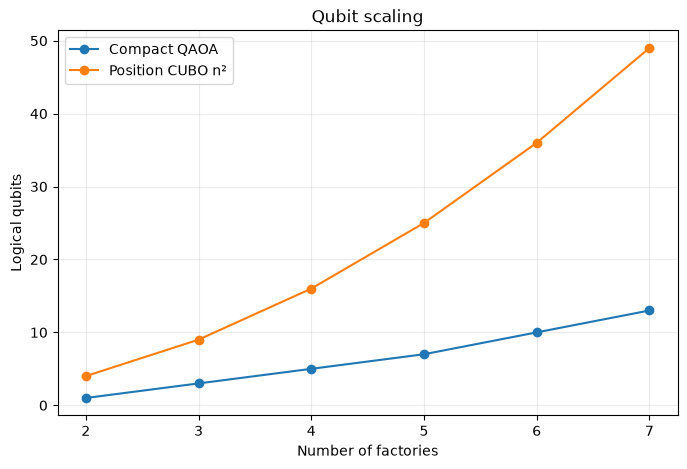

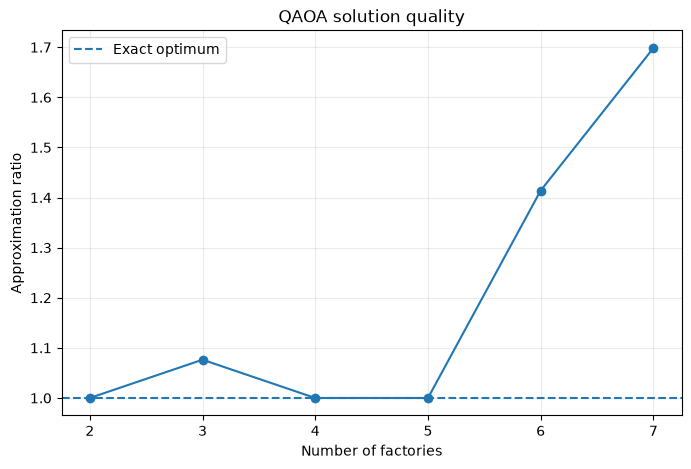

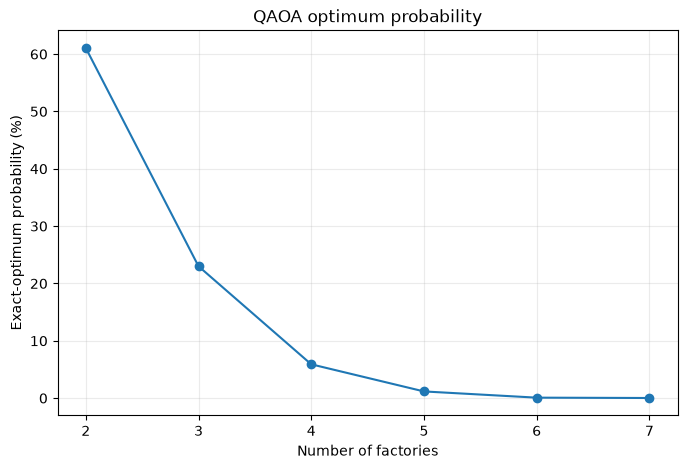

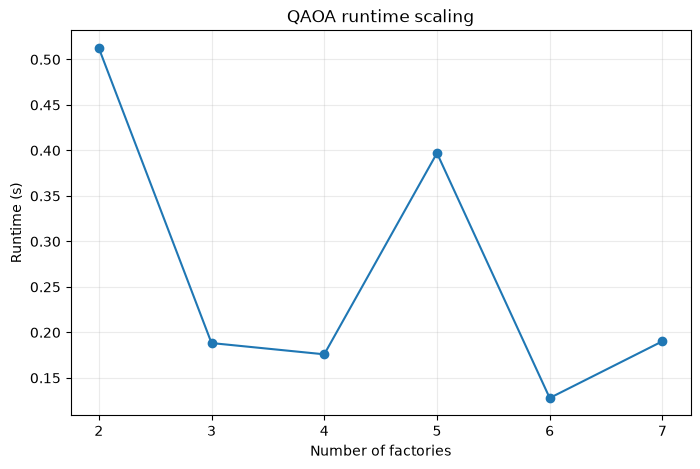

In [16]:
plt.figure(figsize=(8,5))
plt.plot(scaling_results_df['Factories'], scaling_results_df['Compact_Qubits'], marker='o', label='Compact QAOA')
plt.plot(scaling_results_df['Factories'], scaling_results_df['Position_CUBO_Qubits'], marker='o', label='Position CUBO n²')
plt.xlabel('Number of factories'); plt.ylabel('Logical qubits'); plt.title('Qubit scaling')
plt.xticks(SCALING_SIZES); plt.grid(alpha=.25); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(scaling_results_df['Factories'], scaling_results_df['Mode_Approximation_Ratio'], marker='o')
plt.axhline(1.0, linestyle='--', label='Exact optimum')
plt.xlabel('Number of factories'); plt.ylabel('Approximation ratio'); plt.title('QAOA solution quality')
plt.xticks(SCALING_SIZES); plt.grid(alpha=.25); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(scaling_results_df['Factories'], 100*scaling_results_df['Optimal_Probability'], marker='o')
plt.xlabel('Number of factories'); plt.ylabel('Exact-optimum probability (%)'); plt.title('QAOA optimum probability')
plt.xticks(SCALING_SIZES); plt.grid(alpha=.25); plt.show()

plt.figure(figsize=(8,5))
plt.plot(scaling_results_df['Factories'], scaling_results_df['Runtime_seconds'], marker='o')
plt.xlabel('Number of factories'); plt.ylabel('Runtime (s)'); plt.title('QAOA runtime scaling')
plt.xticks(SCALING_SIZES); plt.grid(alpha=.25); plt.show()

## 11. Inspect top states and leg-by-leg route details

In [17]:
INSPECT_N = 7  # change to 2,3,4,5,6,7
print(f'Top states for {INSPECT_N} factories')
display(all_results[INSPECT_N]['top_probability_df'])

inst, r = all_instances[INSPECT_N], all_results[INSPECT_N]
order = tuple(r['mode_route'].replace(DEPOT+' -> ','').replace(' -> '+DEPOT,'').split(' -> '))
leg_df = pd.DataFrame(evaluate_route(order, inst['deliveries'])['legs'])
print(r['mode_route'])
display(leg_df)

Top states for 7 factories


,State_Rank,Bitstring,Probability,Observed_Count,Feasible,Route,Cost_KSh
0,650,0001010001010,0.000394,4,True,Karatina -> Mukangu -> Thunguri -> Kianjega ->...,13743.622367
1,771,0001100000011,0.000391,0,True,Karatina -> Ragati -> Mukangu -> Nguguini -> C...,12417.139101
2,129,0000010000001,0.000385,3,True,Karatina -> Mukangu -> Chema -> Ragati -> Ngug...,11147.300046
3,770,0001100000010,0.000385,2,True,Karatina -> Ragati -> Mukangu -> Nguguini -> C...,11379.125237
4,106,0000001101010,0.000381,1,True,Karatina -> Mukangu -> Ragati -> Thunguri -> K...,14649.716252
5,822,0001100110110,0.000381,0,True,Karatina -> Ragati -> Mukangu -> Thunguri -> K...,14048.074393
6,128,0000010000000,0.000380,4,True,Karatina -> Mukangu -> Chema -> Ragati -> Ngug...,10109.286182
7,279,0000100010111,0.000380,2,True,Karatina -> Mukangu -> Kianjega -> Chema -> Ki...,13056.182593
8,229,0000011100101,0.000378,3,True,Karatina -> Mukangu -> Chema -> Thunguri -> Ng...,15709.617253
9,654,0001010001110,0.000378,2,True,Karatina -> Mukangu -> Thunguri -> Kianjega ->...,13719.238141


Karatina -> Mukangu -> Thunguri -> Kianjega -> Ragati -> Nguguini -> Chema -> Kiangai -> Karatina


,From,To,Load_t,Delivered_t,Distance_km,Time_h,Tonne_km,Cost_KSh
0,Karatina,Mukangu,1.000000e+01,0.992683,10.08,0.22,1.008000e+02,1.612800e+03
1,Mukangu,Thunguri,9.007317e+00,1.590501,24.62,0.56,2.217601e+02,3.548162e+03
2,Thunguri,Kianjega,7.416816e+00,1.049294,32.26,0.63,2.392665e+02,3.828264e+03
3,Kianjega,Ragati,6.367522e+00,1.214377,25.51,0.42,1.624355e+02,2.598968e+03
4,Ragati,Nguguini,5.153145e+00,3.127599,15.86,0.38,8.172888e+01,1.307662e+03
5,Nguguini,Chema,2.025546e+00,0.464185,9.84,0.23,1.993137e+01,3.189019e+02
6,Chema,Kiangai,1.561361e+00,1.561361,21.17,0.51,3.305401e+01,5.288641e+02
7,Kiangai,Karatina,-2.220446e-16,0.000000,20.02,0.29,-4.445333e-15,-7.112533e-14


## 12. Optional QAOA depth sensitivity — p = 1, 2, 3

In [18]:
DEPTH_TEST_N = 4
DEPTH_VALUES = [1,2,3]
depth_rows = []
for p in DEPTH_VALUES:
    print(f'Running p={p} on {DEPTH_TEST_N} factories...')
    r = solve_qaoa_instance(all_instances[DEPTH_TEST_N], p=p, seed=MASTER_SEED+50000)
    depth_rows.append({
        'Factories':DEPTH_TEST_N,'QAOA_p':p,'Qubits':r['n_qubits'],
        'Approximation_Ratio':r['mode_ratio'],'Optimal_Probability':r['optimal_probability'],
        'Feasible_Probability':r['feasible_probability'],'Runtime_seconds':r['runtime_seconds'],
    })
depth_test_df = pd.DataFrame(depth_rows)
display(depth_test_df)

Running p=1 on 4 factories...
Running p=2 on 4 factories...
Running p=3 on 4 factories...


,Factories,QAOA_p,Qubits,Approximation_Ratio,Optimal_Probability,Feasible_Probability,Runtime_seconds
0,4,1,5,1.000000,0.058989,0.999069,0.173718
1,4,2,5,1.000000,0.058733,0.999091,0.414910
2,4,3,5,1.046752,0.119960,0.994482,0.459449


## 13. Build the Qiskit circuit and optionally run it on qBraid

In [19]:
def build_qiskit_qaoa_circuit(instance, result, p=QAOA_P, measure=True):
    energies, nq = instance['energies'], instance['n_qubits']
    params = result['optimal_params']
    gammas, betas = np.asarray(params[:p]), np.asarray(params[p:2*p])
    qc = QuantumCircuit(nq)
    qc.h(range(nq))
    for layer in range(p):
        qc.append(DiagonalGate(np.exp(-1j*gammas[layer]*energies).tolist()), list(range(nq)))
        for q in range(nq): qc.rx(2*betas[layer], q)
    if measure: qc.measure_all()
    return qc

# Mentor step: build the 2-factory circuit first.
qaoa_circuit_2 = build_qiskit_qaoa_circuit(instance_2, result_2)
print(qaoa_circuit_2)
print('Qubits:', qaoa_circuit_2.num_qubits)
print('Logical depth:', qaoa_circuit_2.depth())

        ┌───┐┌──────────────────────────────────────────────┐┌────────────┐ ░ »
     q: ┤ H ├┤ Diagonal(-0.17034+0.98539j,-0.3842+0.92325j) ├┤ Rx(4.7058) ├─░─»
        └───┘└──────────────────────────────────────────────┘└────────────┘ ░ »
meas: 1/══════════════════════════════════════════════════════════════════════»
                                                                              »
«        ┌─┐
«     q: ┤M├
«        └╥┘
«meas: 1/═╩═
«         0 
Qubits: 1
Logical depth: 4


In [ ]:
# OPTIONAL qBRAID QIR EXECUTION
# Start at QBRAID_N = 2. After it works, change to 3, 4, ...
#
# from qbraid import QbraidProvider
#
# QBRAID_N = 2
# circuit = build_qiskit_qaoa_circuit(all_instances[QBRAID_N], all_results[QBRAID_N])
#
# provider = QbraidProvider()
# device = provider.get_device('qbraid:qbraid:sim:qir-sv')
# job = device.run(circuit, shots=SHOTS)
# cloud_result = job.result()
# counts = cloud_result.data.get_counts()
# print(counts)

## 14. Save all mentor-scaling results to Excel

In [20]:
OUTPUT_FILE = 'QSOLVE_QAOA_Scaling_2_to_7_Factories.xlsx'

tops = []
for n in SCALING_SIZES:
    t = all_results[n]['top_probability_df'].copy()
    t.insert(0, 'Factories', n)
    tops.append(t)
top_states_df = pd.concat(tops, ignore_index=True)

with pd.ExcelWriter(OUTPUT_FILE, engine='openpyxl') as writer:
    scaling_results_df.to_excel(writer, sheet_name='Scaling_Results', index=False)
    resource_df.to_excel(writer, sheet_name='Qubit_Resources', index=False)
    instance_loads_df.to_excel(writer, sheet_name='Scaled_Deliveries', index=False)
    validation_df.to_excel(writer, sheet_name='Constraint_Checks', index=False)
    top_states_df.to_excel(writer, sheet_name='Top_QAOA_States', index=False)
    scaling_order_df.to_excel(writer, sheet_name='Factory_Addition_Order', index=False)

print('Saved:', OUTPUT_FILE)

Saved: QSOLVE_QAOA_Scaling_2_to_7_Factories.xlsx


## How to present the experiment

Use the sequence as six increasing instances:

| Instance | Factories | Possible routes | Compact qubits |
|---|---:|---:|---:|
| I1 | 2 | 2 | 1 |
| I2 | 3 | 6 | 3 |
| I3 | 4 | 24 | 5 |
| I4 | 5 | 120 | 7 |
| I5 | 6 | 720 | 10 |
| I6 | 7 | 5040 | 13 |

For each instance report exact cost, QAOA cost, approximation ratio, optimum probability, feasible-state probability, and runtime.

### Scientific limitation
The exact classical benchmark is easy here because the largest case has only `7! = 5040` routes. The purpose is to measure **quantum solution quality and scaling behavior**, not to claim quantum advantage. The full 233.7-tonne logistics problem remains hybrid, with classical capacity/trip decomposition and a quantum route-ordering component.